In [2]:
# Klasyfikacja obiektów astronomicznych SDSS17

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

Wczytanie Danych

In [ ]:
from datasets import load_dataset

dataset = load_dataset("AethronPhantom/Astro")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/5.67k [00:00<?, ?B/s]

star_classification.csv:   0%|          | 0.00/16.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift', 'plate', 'MJD', 'fiber_ID'],
        num_rows: 100000
    })
})


In [ ]:
df = dataset["train"].to_pandas()

print("Rozmiar danych:", df.shape)
df.head()

# Opis datasetu

print("Nazwy kolumn:")
print(df.columns)

print("\nInformacje o danych:")
df.info()

# Sprawdzamy braki w danych
print("Liczba brakujących wartości w każdej kolumnie:")
print(df.isnull().sum())


Rozmiar danych: (100000, 18)
Nazwy kolumn:
Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='object')

Informacje o danych:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID 

Analiza klas STAR / GALAXY / QSO

Liczebność klas:
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


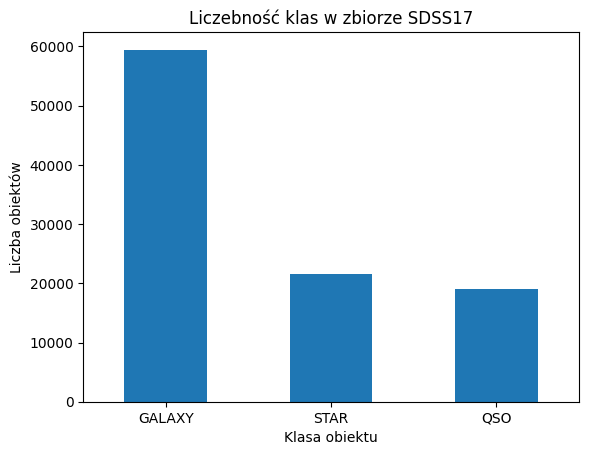

In [ ]:
import matplotlib.pyplot as plt

print("Liczebność klas:")
print(df["class"].value_counts())

df["class"].value_counts().plot(kind="bar")

plt.title("Liczebność klas w zbiorze SDSS17")
plt.xlabel("Klasa obiektu")
plt.ylabel("Liczba obiektów")
plt.xticks(rotation=0)
plt.show()

Przygotowanie danych

In [ ]:
# Wybór cech wejściowych

features = ["alpha", "delta", "u", "g", "r", "i", "z", "redshift"]
X = df[features]

# Zmienna docelowa
Y = df["class"]

print("Rozmiar X:", X.shape)
print("Rozmiar Y:", Y.shape)



Rozmiar X: (100000, 8)
Rozmiar Y: (100000,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# zdefiniujemy etykiety i zakodujemy klasy
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(Y)

print("Mapowanie klas")

for i, cls in enumerate(encoder.classes_):
  print(i, "->", cls)

Mapowanie klas
0 -> GALAXY
1 -> QSO
2 -> STAR


In [ ]:
from sklearn.model_selection import train_test_split

# Podział danych

X_train, X_temp, Y_train, Y_temp = train_test_split(X, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded)
# otzrymamy 70% train i 30% tymczasowy
# dzielimy te 30% na pół
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.50, random_state=42, stratify=Y_temp)
# dostajemy 70% train, 15 % validation i 15% test

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

# Skalowanie
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train: (70000, 8)
X_val  : (15000, 8)
X_test : (15000, 8)


Model 1 - Random Forest

Random Forest - accuracy na zbiorze walidacyjnym: 0.9772
              precision    recall  f1-score   support

      GALAXY       0.97      0.99      0.98      8917
         QSO       0.97      0.92      0.94      2844
        STAR       0.99      1.00      1.00      3239

    accuracy                           0.98     15000
   macro avg       0.98      0.97      0.97     15000
weighted avg       0.98      0.98      0.98     15000



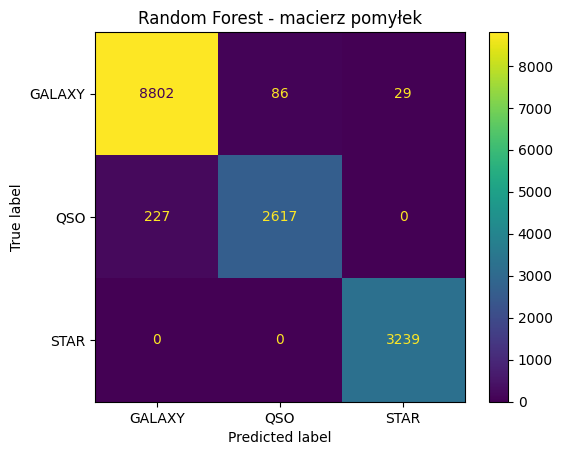

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Tworzymy model Random Forest

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Trenujemy model na zbiorze treningowym
rf_model.fit(X_train_scaled, Y_train)

# Predykcja na zbiorze walidacyjnym
Y_val_pred_rf = rf_model.predict(X_val_scaled)

# Ocena modelu na zbiorze walidacyjnym
rf_accuracy = accuracy_score(Y_val, Y_val_pred_rf)
print("Random Forest - accuracy na zbiorze walidacyjnym:", rf_accuracy)

# Dokładniejszy raport klasyfikacji
print(classification_report(Y_val, Y_val_pred_rf, target_names=encoder.classes_))

# Macierz pomyłek
cm_rf = confusion_matrix(Y_val, Y_val_pred_rf)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=encoder.classes_)

disp_rf.plot()
plt.title("Random Forest - macierz pomyłek")
plt.show()

Model 2 - Gradient Bossting

Gradient Boosting - accuracy: 0.9748666666666667
              precision    recall  f1-score   support

      GALAXY       0.97      0.99      0.98      8917
         QSO       0.96      0.91      0.93      2844
        STAR       1.00      1.00      1.00      3239

    accuracy                           0.97     15000
   macro avg       0.98      0.97      0.97     15000
weighted avg       0.97      0.97      0.97     15000



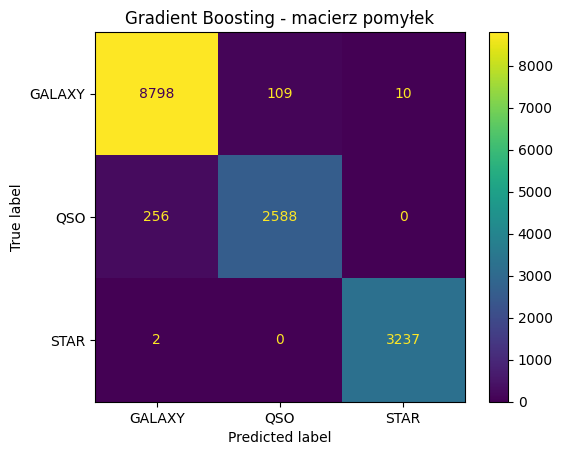

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

# Utworzenie modelu Gradient Boosting

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Trenowanie modelu

gb_model.fit( X_train_scaled, Y_train)

# Predykcja na zbiorze walidacyjnym

Y_val_pred_gb = gb_model.predict( X_val_scaled)

# Accuracy

gb_accuracy = accuracy_score( Y_val, Y_val_pred_gb)

print("Gradient Boosting - accuracy:", gb_accuracy)

# Szczegółowy raport klasyfikacji

print(classification_report( Y_val, Y_val_pred_gb, target_names=encoder.classes_))

# Macierz pomyłek

cm_gb = confusion_matrix( Y_val,Y_val_pred_gb)

disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=encoder.classes_)

disp_gb.plot()

plt.title("Gradient Boosting - macierz pomyłek")
plt.show()

Porównanie modeli

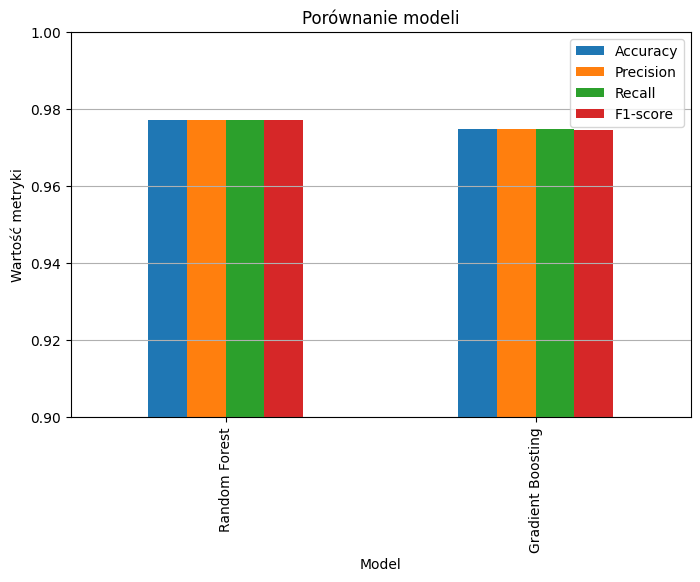

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# Random Forest
rf_precision = precision_score(Y_val, Y_val_pred_rf, average="weighted")
rf_recall = recall_score(Y_val, Y_val_pred_rf, average="weighted")
rf_f1 = f1_score(Y_val, Y_val_pred_rf, average="weighted")

# Gradient Boosting
gb_precision = precision_score(Y_val, Y_val_pred_gb, average="weighted")
gb_recall = recall_score(Y_val, Y_val_pred_gb, average="weighted")
gb_f1 = f1_score(Y_val, Y_val_pred_gb, average="weighted")

# Tabela wyników
results_df = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "Accuracy": [rf_accuracy, gb_accuracy],
    "Precision": [rf_precision, gb_precision],
    "Recall": [rf_recall, gb_recall],
    "F1-score": [rf_f1, gb_f1]
})

results_df
# wykres
results_df.set_index("Model").plot( kind="bar", figsize=(8,5))

plt.title("Porównanie modeli")
plt.ylabel("Wartość metryki")
plt.ylim(0.9, 1.0)
plt.grid(axis="y")
plt.show()

Oba modele osiągneły bardzo wysoka skuteczność klasyfikacji. Lepsze wyniki uzyskał model Random Forest, który osiagnął accuracy około 98%. Najwieksze różncie pomiedzy modelami wystapiły dla klasy QSA, gdzie RF uzyskał nieco wyższe wartości recall i F1-scorte

Wazńość cech

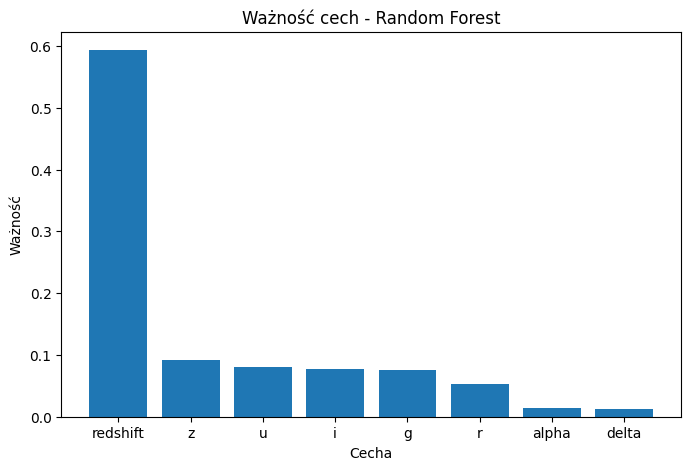

In [ ]:
feature_importance = pd.DataFrame({"Cecha": features, "Ważność": rf_model.feature_importances_})

feature_importance = feature_importance.sort_values(by="Ważność", ascending=False)
feature_importance

plt.figure(figsize=(8,5))

plt.bar(feature_importance["Cecha"], feature_importance["Ważność"])
plt.title("Ważność cech - Random Forest")
plt.xlabel("Cecha")
plt.ylabel("Ważność")
plt.show()

**Eksperyment bez redshift. **
W poprzednim kroku analiza ważność cech wykazała, że redshift jest najważniejszą cechą wykorzystywaną przez model.
W tym eksperymencie sprawdzimy, jak zmieni się skuteczność klasyfikacji po usunieciu tej cechy.
Jeśli wyniki się pogorszą, będzie to oznaczało, że redshift jest kluczową informacją przy rozpoznawaniu gwiazd, galaktyk i kwazarów.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Tworzymy nowy zestaw cech bez kolumny redshift

features_no_redshift = ["alpha","delta","u","g","r","i", "z"]

X_no_redshift = df[features_no_redshift]

# Ponownie dzielimy dane na zbiory:
# treningowy (70%), walidacyjny (15%) i testowy (15%)

X_train_nr, X_temp_nr, y_train_nr, y_temp_nr = train_test_split(X_no_redshift, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded)

X_val_nr, X_test_nr, y_val_nr, y_test_nr = train_test_split( X_temp_nr,y_temp_nr, test_size=0.50, random_state=42,stratify=y_temp_nr)

# Skalowanie danych

scaler_nr = StandardScaler()

X_train_nr_scaled = scaler_nr.fit_transform(X_train_nr)
X_val_nr_scaled = scaler_nr.transform(X_val_nr)
X_test_nr_scaled = scaler_nr.transform(X_test_nr)

# Tworzenie modelu Random Forest

rf_no_redshift = RandomForestClassifier( n_estimators=100, random_state=42, class_weight="balanced")

# Trenowanie modelu

rf_no_redshift.fit( X_train_nr_scaled, y_train_nr)

# Predykcja na zbiorze walidacyjnym

y_val_pred_nr = rf_no_redshift.predict( X_val_nr_scaled)

# Ocena skuteczności modelu

acc_no_redshift = accuracy_score( y_val_nr,y_val_pred_nr)

print("Random Forest bez cechy redshift")
print("Accuracy:", acc_no_redshift)
print()

print(classification_report( y_val_nr, y_val_pred_nr, target_names=encoder.classes_))

Random Forest bez cechy redshift
Accuracy: 0.8739333333333333

              precision    recall  f1-score   support

      GALAXY       0.91      0.95      0.93      8917
         QSO       0.81      0.80      0.80      2844
        STAR       0.83      0.73      0.78      3239

    accuracy                           0.87     15000
   macro avg       0.85      0.83      0.84     15000
weighted avg       0.87      0.87      0.87     15000



Porówanie modelu z redshift i bez

,Model,Accuracy
0,Random Forest (z redshift),0.977200
1,Random Forest (bez redshift),0.873933


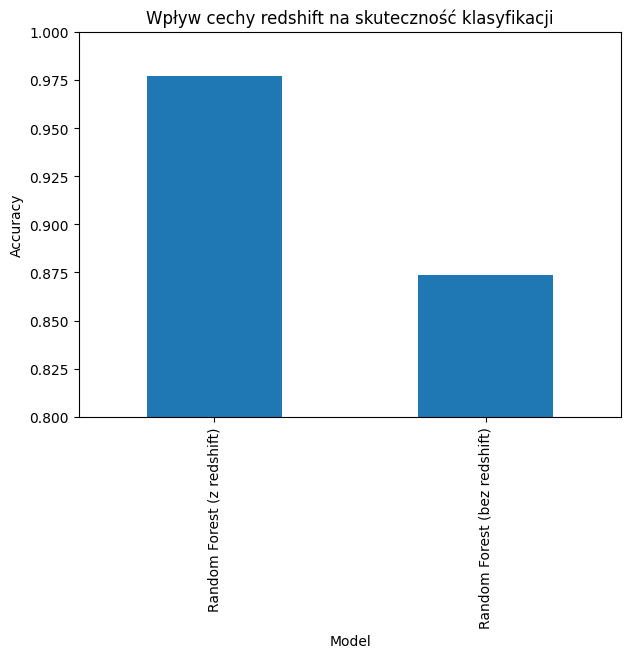

In [ ]:
comparison_redshift = pd.DataFrame({"Model": [ "Random Forest (z redshift)", "Random Forest (bez redshift)"],"Accuracy": [rf_accuracy,acc_no_redshift]})

display(comparison_redshift)

comparison_redshift.plot(x="Model",y="Accuracy",kind="bar",legend=False,figsize=(7,5))

plt.title("Wpływ cechy redshift na skuteczność klasyfikacji")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)

plt.show()

===== PODSUMOWANIE =====
Random Forest accuracy: 0.9772
Gradient Boosting accuracy: 0.9749
Random Forest bez redshift accuracy: 0.8739
               Model  Accuracy
0      Random Forest  0.977200
1  Gradient Boosting  0.974867
2    RF bez redshift  0.873933


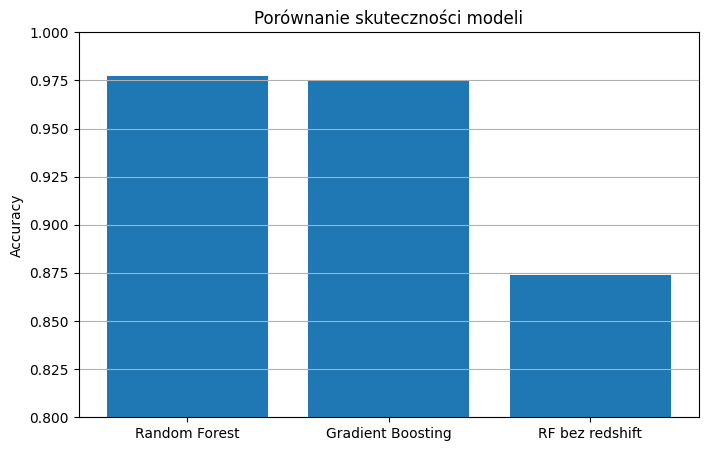

In [ ]:
# Zapisanie wyników końcowych

print("===== PODSUMOWANIE =====")
print(f"Random Forest accuracy: {rf_accuracy:.4f}")
print(f"Gradient Boosting accuracy: {gb_accuracy:.4f}")
print(f"Random Forest bez redshift accuracy: {acc_no_redshift:.4f}")

# WYKRES DO PORÓWNANIA MODELI
comparison_df = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "RF bez redshift"
    ],
    "Accuracy": [
        rf_accuracy,
        gb_accuracy,
        acc_no_redshift
    ]
})

print(comparison_df)

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Porównanie skuteczności modeli")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)

plt.grid(axis="y")

plt.savefig(
    "accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Cecha,Importance
7,redshift,0.486420
6,z,0.026893
3,g,0.020140
2,u,0.014493
5,i,0.012367
4,r,0.004147
1,delta,0.000707
0,alpha,0.000500


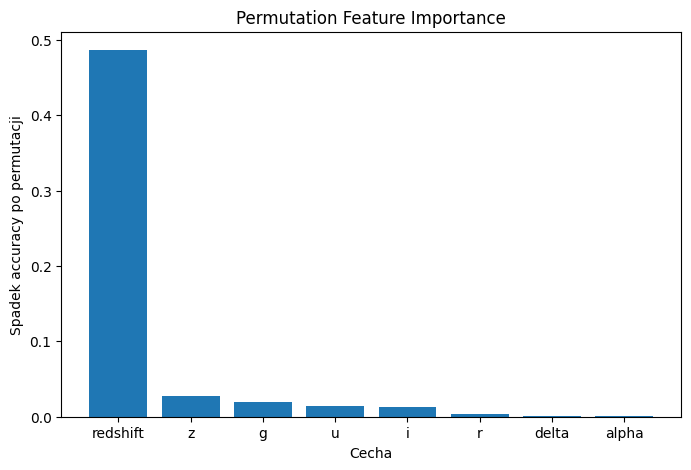

In [ ]:
from sklearn.inspection import permutation_importance

# PERMUTATION IMPORTANCE
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    rf_model,
    X_val_scaled,
    Y_val,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    "Cecha": features,
    "Importance": perm_importance.importances_mean
})

perm_df = perm_df.sort_values(
    by="Importance",
    ascending=False
)

display(perm_df)

plt.figure(figsize=(8,5))

plt.bar(
    perm_df["Cecha"],
    perm_df["Importance"]
)

plt.title("Permutation Feature Importance")
plt.xlabel("Cecha")
plt.ylabel("Spadek accuracy po permutacji")

plt.show()